# 튜토리얼: ChemBERTa — SMILES 토큰화 전략을 이용한 분자 물성 예측을 위한 대규모 자기지도(Self-Supervised) 사전학습

![alt text](https://huggingface.co/front/assets/huggingface_mask.svg)

작성: Seyone Chithrananda ([Twitter](https://twitter.com/SeyoneC))

화학·재료과학을 위한 딥러닝은 잠재력이 큰 신생 분야입니다. 그러나 자연어 처리(NLP)나 컴퓨터 비전에서 인기를 끈 전이학습(transfer learning) 기반 기법들은, 아직 계산화학+머신러닝 분야에서 효과적으로 발전하지 못했습니다. HuggingFace의 모델군과 ByteLevel 토크나이저를 사용하여, 우리는 잘 알려진 벤치마크 화학 데이터셋인 PubChem에서 가져온 10,000,000개의 SMILES 문자열 대규모 말뭉치(corpus)로 대형 트랜스포머 모델 RoBERTa를 학습시킬 수 있습니다.

RoBERTa를 10 에폭 동안 학습하면 모델은 0.198이라는 꽤 좋은 손실(loss)에 도달하며, 더 많은 에폭으로 학습하면 계속 수렴할 가능성이 높습니다. 이 모델은 SMILES 시퀀스/분자 내에서 가려지거나(masked) 손상된(corrupted) 토큰을 예측할 수 있어, 발견 가능한 화학 공간(chemical space) 내에서 한 분자의 변형(variant)을 예측할 수 있게 해줍니다.

모델이 학습한 작용기(functional group)와 원자의 표현(representation)을 적용하면, 학습된 표현을 특징으로 삼아 더 작은 데이터셋에서 독성(toxicity), 용해도(solubility), 약물 유사성(drug-likeness), 합성 접근성(synthesis accessibility) 같은 문제를 다룰 수 있습니다. 이는 분자의 그래프 구조에 대한 그래프 합성곱·어텐션 모델의 특징으로 쓰이거나, BERT의 미세조정(fine-tuning)에 사용될 수 있습니다. 마지막으로, 우리는 어텐션 시각화(attention visualization)를 화학 실무자와 학생들이 다양한 화학적 성질에서 중요한 부분 구조(substructure)를 빠르게 식별하는 유용한 도구로 제안합니다.

또한 어텐션 메커니즘의 시각화는 기존 연구에서 화학 반응 분류에 매우 가치 있는 것으로 밝혀졌습니다. HuggingFace로 RoBERTa 같은 대규모 트랜스포머 모델을 오픈소스화하면, 이러한 개별 연구 방향의 가속을 도울 수 있습니다.

학습·업로드·평가 노트북(렘데시비르 같은 화합물에 대한 예측 샘플 포함)이 들어 있는 저장소 링크는 [여기](https://github.com/seyonechithrananda/bert-loves-chemistry)에서 확인할 수 있습니다. 모든 노트북은 새 Colab 런타임으로 복사해 쉽게 실행할 수 있습니다. 이 저장소에는 어텐션 시각화, 더 쉬운 벤치마킹 인프라 등 새로운 기능이 계속 추가될 예정입니다. 이 튜토리얼의 바탕이 된 연구는 [Arxiv](https://arxiv.org/abs/2010.09885)에 게재되었으며, **NeurIPS 2020의 ML for Molecules Workshop에서 포스터 발표로 채택**되었습니다.

이 튜토리얼에서는, 계산화학에 적용된 HuggingFace의 NLP 기반 전이학습의 잠재력과 효과를 보여주기 위해, 사전학습된 ChemBERTa를 소규모 분자 데이터셋인 Clintox에서 미세조정하겠습니다. 가독성을 위해 일부 셀의 출력은 일부러 지워두었으니, 여러분의 셀 출력 메시지가 조금 달라도 걱정하지 마세요!

요약하면, 이 노트북에서 다룰 주요 구성 요소는 세 가지입니다.
1. SMILES 문자열에 대한 가려진 토큰(masked token) 추론 예측
2. PubChem-10M 모델의 어텐션 시각화
3. ClinTox 독성 데이터셋에서 BPE-ChemBERTa와 Smiles-Tokenizer ChemBERTa 모델 미세조정

**이 용어들이 익숙하지 않아도 걱정하지 마세요. 튜토리얼 뒷부분에서 설명합니다!**

더 깊이 들어가고 싶다면 [여기](https://seyonechithrananda.com/ChemBERTa-DeepChem-e1244b82c8fb40bca8c3c882acb9baa5)의 포스터를 확인하세요.

## Colab에서 실행하기

이 튜토리얼은 Google Colab 환경을 기준으로 설계되었습니다(보조 저장소 clone과 `/content/...` 경로 사용). 원활한 실행을 위해 Colab을 권장합니다. (Kaggle에서도 열 수 있습니다.)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/isg-yhlee93/lecture/blob/main/Molecular%20Machine%20Learning/7_Transfer_Learning_With_ChemBERTa_Transformers.ipynb)
[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https://github.com/isg-yhlee93/lecture/blob/main/Molecular%20Machine%20Learning/7_Transfer_Learning_With_ChemBERTa_Transformers.ipynb)


## 설치(Setup)

아래 셀들을 실행하여 DeepChem과 필요한 패키지들을 설치합니다.


In [ ]:
!pip install -qq --pre deepchem
import deepchem

# 불필요한 경고 메시지 끄기 (화면을 깔끔하게 보기 위함)
import warnings
warnings.filterwarnings('ignore')

deepchem.__version__


In [ ]:
from rdkit import Chem

# RDKit 로그 끄기
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')


이번에는 학습과 어텐션 시각화에 필요한 라이브러리들을 설치합니다.

(참고: 원래 튜토리얼은 16비트 혼합 정밀도 학습을 위해 NVIDIA의 Apex 도구를 설치했습니다. 하지만 현재 PyTorch는 혼합 정밀도 기능을 내장(`torch.cuda.amp`)하고 있어, Apex를 별도로 설치할 필요가 없습니다.)


In [ ]:
# 학습/시각화에 필요한 패키지를 설치합니다.
# (참고: 예전 튜토리얼은 simpletransformers를 썼지만, 최신 transformers와 호환되지 않아
#  여기서는 HuggingFace 표준인 transformers의 Trainer + datasets로 미세조정합니다.)
!pip install -qq transformers datasets regex


In [ ]:
import sys
# 어텐션 시각화 도구인 bertviz 저장소를 받아옵니다.
!test -d bertviz_repo && echo "FYI: bertviz_repo directory already exists, to pull latest version uncomment this line: !rm -r bertviz_repo"
# !rm -r bertviz_repo # 저장소를 깨끗이 다시 받고 싶다면 주석을 해제하세요
!test -d bertviz_repo || git clone https://github.com/jessevig/bertviz bertviz_repo
if not 'bertviz_repo' in sys.path:
  sys.path += ['bertviz_repo']


이번에는 보조 저장소인 bert-loves-chemistry를 복제(clone)하겠습니다. 이를 통해 ChemBERTa용 MolNet 데이터로더를 사용할 수 있는데, 이 로더는 어떤 MoleculeNet 데이터셋에서든 스캐폴드 분할(scaffold split)을 자동으로 생성해 줍니다!


In [ ]:
!git clone https://github.com/seyonechithrananda/bert-loves-chemistry.git


In [ ]:
!nvidia-smi


# 토크나이저(Tokenizer)란 무엇인가?

토크나이저는 자연어 처리 모델의 입력을 준비하는 역할을 합니다. 많은 과학적 응용에서, 입력을 "단어"/"문장"처럼 다루고 NLP 기법을 적용해 의미 있는 예측을 할 수 있습니다. 예를 들어 SMILES 문자열이나 DNA 서열은 문법적 구조를 가지므로 NLP 기법으로 유용하게 모델링할 수 있습니다. DeepChem은 다양한 응용에 쓸 수 있는, 과학적으로 의미 있는 토크나이저들을 제공합니다. 이 토크나이저들은 HuggingFace transformers 라이브러리의 것을 기반으로 합니다(DeepChem 토크나이저가 이를 상속합니다).

HuggingFace의 기반 클래스 PreTrainedTokenizer와 PreTrainedTokenizerFast는, 문자열 입력을 모델 입력으로 인코딩하고, 로컬 파일/디렉터리나 (HuggingFace의 AWS S3 저장소에서 내려받은) 사전학습 토크나이저로부터 파이썬 토크나이저를 생성·저장하는 공통 메서드를 구현합니다.

PreTrainedTokenizer [(transformers.PreTrainedTokenizer)](https://huggingface.co/transformers/main_classes/tokenizer.html#transformers.PreTrainedTokenizer))는 모든 토크나이저를 사용하기 위한 주요 메서드를 구현합니다:
* 토큰화(문자열을 하위 단어 토큰 문자열로 분할), 토큰 문자열을 id로 또는 그 반대로 변환, 인코딩/디코딩(즉 토큰화 + 정수 변환),

* 기반 구조(BPE, SentencePiece 등)와 무관하게 어휘에 새 토큰 추가,

* 마스크(mask), 문장 시작(beginning-of-sentence) 등 특수 토큰 관리(추가하고, 쉽게 접근하도록 토크나이저 속성에 할당하며, 토큰화 중에 분리되지 않도록 보장)

ChemBERTa가 기본으로 사용하는 토크나이저는 Byte-Pair-Encoder(BPE)입니다. 이는 문자 수준과 단어 수준 표현의 중간 형태로, 자연어 말뭉치의 큰 어휘를 다룰 수 있게 해줍니다. 드물거나 알려지지 않은 단어는 종종 여러 개의 알려진 하위 단어(subword)로 분해될 수 있다는 직관에서 출발하여, BPE는 빈번한 문자 쌍을 반복적·탐욕적으로 병합하며 최적의 단어 분할을 찾아냅니다.


먼저 모델의 Byte-Pair Encoding 토크나이저와 모델을 불러오고, 가려진 토큰 예측(masked token prediction)을 위한 HuggingFace 파이프라인을 설정해 봅시다.


In [ ]:
from transformers import AutoModelForMaskedLM, AutoTokenizer, pipeline, RobertaModel, RobertaTokenizer
from bertviz import head_view

# HuggingFace 허브에서 사전학습된 ChemBERTa(BPE) 모델과 토크나이저를 불러옵니다.
model = AutoModelForMaskedLM.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")
tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")

# 가려진 토큰을 채우는(fill-mask) 파이프라인을 만듭니다.
fill_mask = pipeline('fill-mask', model=model, tokenizer=tokenizer)


# 트랜스포머(Transformer) 모델이란 무엇인가?

앞에서 우리는 현대 딥러닝 모델의 어텐션(attention) 메커니즘에 대해 이야기했습니다. 어텐션은 신경망 기계 번역(neural machine translation) 응용의 성능을 끌어올리는 데 기여한 개념입니다. **트랜스포머(Transformer)**는 어텐션을 사용해 이러한 모델들의 학습 속도를 높이는 모델입니다.

2018년 Google AI의 BERT가 등장하면서, 트랜스포머는 떠오르는 딥러닝 기법의 정상에 빠르게 올라, 수십 가지 과제에서 seq2seq나 순환신경망(RNN) 같은 신경망 기계 번역 모델을 능가했습니다.

하지만 가장 큰 이점은 트랜스포머가 효율적인 **사전학습(pre-training)**에 적합하다는 점에서 나옵니다. BERT의 후속 연구인 RoBERTa가 사용한 사전학습 절차(토큰의 15%를 마스킹)를 그대로 사용하여, 우리는 각 SMILES 문자열에서 토큰의 15%를 마스킹하고 최대 시퀀스 길이를 256자로 지정합니다.

그러면 모델은 **원자와 작용기로 이루어진 가려진 토큰을 예측하는 법**을 학습합니다. 작용기란 고유한 특성을 갖는 분자 내 특정 원자 그룹입니다. 이를 통해 모델은 물성 예측 같은 전이 가능한 과제에 필요한 분자적 맥락(molecular context)을 학습합니다.

ChemBERTa는 양방향(bidirectional) 학습 맥락을 사용하여, 자기지도 사전학습을 위해 MoleculeNet으로 내려받을 수 있는 PubChem 10M 데이터셋([링크](https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/pubchem_10m.txt.zip))의 맥락 인식(context-aware) 표현을 학습합니다. 우리가 사용하는 BERT 트랜스포머 변형은 12개의 어텐션 헤드(attention head)와 6개의 층(layer)을 사용하여, 총 72개의 서로 다른 어텐션 메커니즘을 갖습니다.

트랜스포머는 논문 "Attention is All You Need"에서 제안되었습니다.


이제 ChemBERTa 모델이 화학적 문법과 분자 구조를 이해하는지 확인하기 위해, 벤젠 SMILES 분자 안의 가려진 토큰/문자를 예측하는 과제로 테스트하겠습니다. 앞에서 초기화한 HuggingFace 파이프라인을 사용하면, 모델의 예측을 신뢰도 점수(confidence score) 순으로 정렬된 목록으로 가져올 수 있습니다:


In [ ]:
smiles_mask = "C1=CC=CC<mask>C1"
smiles = "C1=CC=CC=C1"

# 가려진 위치에 들어갈 토큰을 예측합니다.
masked_smi = fill_mask(smiles_mask)

for smi in masked_smi:
  print(smi)


여기서 흥미로운 결과를 얻습니다. 마지막 분기인 `C1=CC=CC=C1`은 벤젠 고리(benzene ring)입니다. 꽤 흔한 분자이기 때문에 모델은 마지막 탄소 이중 결합을 0.98의 점수로 쉽게 예측합니다. 상위 5개 예측(목표 분자인 렘데시비르 포함)의 목록을 얻어, (마지막 벤젠 유사 패턴의 시작 부분을 강조하여) 시각화해 봅시다. 시각화에는 앞에서 설치한 RDKit 케모인포매틱스 패키지, 특히 `rdkit.chem.Draw` 모듈을 사용하겠습니다.


In [ ]:
import torch
import rdkit
import rdkit.Chem as Chem
from rdkit.Chem import rdFMCS
from matplotlib import colors
from rdkit.Chem import Draw
from rdkit.Chem.Draw import MolToImage
from PIL import Image


def get_mol(smiles):
    # SMILES에서 RDKit 분자 객체를 만들고 케큘레화(Kekulize)합니다.
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    Chem.Kekulize(mol)
    return mol


def find_matches_one(mol,submol):
    # mol 안에서 부분 구조(submol)와 일치하는 모든 원자를 찾습니다.
    match_dict = {}
    mols = [mol,submol] # 쌍대(pairwise) 탐색
    res=rdFMCS.FindMCS(mols) #,ringMatchesRingOnly=True)
    mcsp = Chem.MolFromSmarts(res.smartsString)
    matches = mol.GetSubstructMatches(mcsp)
    return matches

# 분자를 그립니다.
def get_image(mol,atomset):    
    hcolor = colors.to_rgb('green')
    if atomset is not None:
        # 분자 전체를 그리되 지정한 원자 집합을 강조 표시합니다.
        img = MolToImage(mol, size=(600, 600),fitImage=True, highlightAtoms=atomset,highlightColor=hcolor)
    else:
        img = MolToImage(mol, size=(400, 400),fitImage=True)
    return img


In [ ]:
sequence = f"C1=CC=CC={tokenizer.mask_token}1"
substructure = "CC=CC"
image_list = []

input = tokenizer.encode(sequence, return_tensors="pt").to(model.device)  # 모델과 같은 기기(CPU/GPU)로 보냄
mask_token_index = torch.where(input == tokenizer.mask_token_id)[1]

token_logits = model(input)[0]
mask_token_logits = token_logits[0, mask_token_index, :]

# 가려진 위치에 대한 상위 5개 예측 토큰을 가져옵니다.
top_5_tokens = torch.topk(mask_token_logits, 5, dim=1).indices[0].tolist()

for token in top_5_tokens:
  smi = (sequence.replace(tokenizer.mask_token, tokenizer.decode([token])))
  print (smi)
  smi_mol = get_mol(smi)
  substructure_mol = get_mol(substructure)
  if smi_mol is None: # 모델의 토큰 예측이 화학적으로 불가능한 경우
    continue
  Draw.MolToFile(smi_mol, smi+".png")
  matches = find_matches_one(smi_mol, substructure_mol)
  atomset = list(matches[0])
  img = get_image(smi_mol, atomset)
  img.format="PNG" 
  image_list.append(img)


In [ ]:
from IPython.display import Image 

for img in image_list:
  display(img)


위에서 볼 수 있듯이, 모델의 MLM 예측 5개 중 5개가 화학적으로 유효합니다. 전반적으로 모델은 꽤 높은 확신도로 문법을 이해하는 것으로 보입니다.

다만 더 특정한 데이터셋(예: 특정 표적에 대한 후보물질)으로 추가 학습하면, 더 강력한 화학 트랜스포머 모델을 만들 수 있습니다. 이제 우리가 선택한 데이터셋인 ClinTox에서 모델을 미세조정해 봅시다. ChemBERTa는 어떤 MoleculeNet 데이터셋에서도 실행할 수 있지만, 편의를 위해 작고 빠르게 학습되는 ClinTox를 사용하겠습니다.


# 어텐션(Attention)이란 무엇인가?
이전의 순환(recurrent) 모델들은 긴 시퀀스에 대해 고정 길이 벡터를 생성하는 데 어려움을 겪었고, 그 결과 입력 시퀀스의 길이가 길어질수록 성능이 떨어졌습니다.

어텐션은 어느 정도, 우리가 시야의 서로 다른 영역에 시각적 주의를 기울이는 방식이나, 문장 속 단어들을 서로 연관 짓는 방식에서 착안한 것입니다. 인간의 시각적 주의는 특정 하위 영역에 더 높은 초점을 두고 집중하면서도 주변 이미지는 더 낮은 초점으로 인지하게 해주며, 그런 다음 초점을 옮길 수 있게 해줍니다.

마찬가지로, 한 문장이나 가까운 맥락 안에서 단어들 사이의 관계를 설명할 수 있습니다. “eating(먹다)”을 보면, 우리는 곧 음식과 관련된 단어를 읽게 될 것이라고 기대합니다. 색을 나타내는 단어도 음식을 묘사하지만, 아마 “eating”만큼 직접적이지는 않을 것입니다:


---



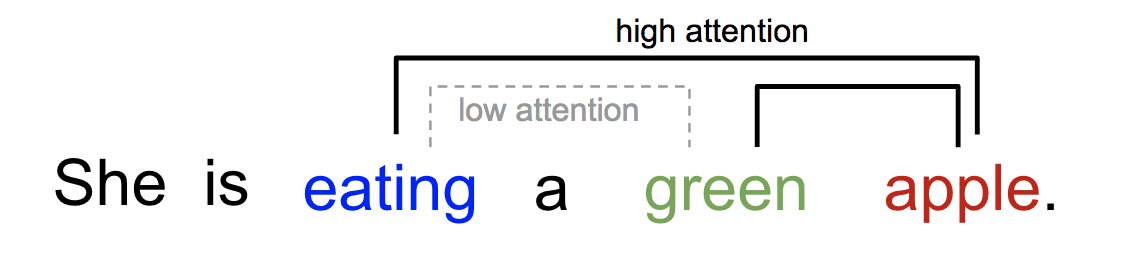


---



어텐션 메커니즘은 인코더-디코더(encoder-decoder) 모델을 확장한 것으로, SMILES 시퀀스에 대해 세 가지 값을 입력받습니다: 값 벡터(value vector, V), 쿼리 벡터(query vector, Q), 키 벡터(key vector, K).

각 벡터는 일종의 단어 임베딩(word embedding)과 비슷하며, 특히 이웃 토큰들의 호환성(compatibility)을 판단하기 위한 것입니다. 이 벡터들로부터, 한 단어의 쿼리 벡터와 다른 단어의 키 벡터의 내적(dot product)을 통해 내적 어텐션(dot-product attention)이 도출됩니다.

키의 차원(dimension)인 $d_k$에 대해 값이 너무 커지지 않도록, 내적 어텐션에는 $\frac{1}{\sqrt{d_k}}$의 스케일링 계수(scaling factor)가 더해집니다. 그런 다음 소프트맥스(softmax) 정규화 함수를 적용하여 각 개별 토큰에 대해 0에서 1 사이의 점수를 반환합니다:

\begin{equation}
    \textrm{Attention}(Q, K, V) = \textrm{softmax} \left (\frac{QK^T}{\sqrt{d_k}} \right )V
\end{equation}



# BertViz로 ChemBERTa의 어텐션 메커니즘 시각화하기

[BertViz](https://github.com/jessevig/bertviz)는 트랜스포머 모델의 어텐션을 시각화하는 도구로, transformers 라이브러리의 모든 모델(BERT, GPT-2, XLNet, RoBERTa, XLM, CTRL 등)을 지원합니다. Llion Jones의 Tensor2Tensor 시각화 도구와 HuggingFace의 transformers 라이브러리를 확장한 것입니다.

이 도구를 사용하면 HuggingFace 모델 허브의 ChemBERTa를 쉽게 연결하여, 특정 트랜스포머 층에서 하나 이상의 어텐션 헤드가 만들어내는 어텐션 패턴을 시각화할 수 있습니다. 이를 어텐션 헤드 뷰(attention-head view)라고 합니다.

먼저 인터랙티브 시각화를 만들기 위해 d3.js와 jquery용 자바스크립트 객체를 가져오는 것부터 시작하겠습니다:


In [ ]:
%%javascript
require.config({
  paths: {
      d3: '//cdnjs.cloudflare.com/ajax/libs/d3/3.4.8/d3.min',
      jquery: '//ajax.googleapis.com/ajax/libs/jquery/2.0.0/jquery.min',
  }
});


In [ ]:
def call_html():
  import IPython
  display(IPython.core.display.HTML('''
        <script src="/static/components/requirejs/require.js"></script>
        <script>
          requirejs.config({
            paths: {
              base: '/static/base',
              "d3": "https://cdnjs.cloudflare.com/ajax/libs/d3/3.5.8/d3.min",
              jquery: '//ajax.googleapis.com/ajax/libs/jquery/2.0.0/jquery.min',
            },
          });
        </script>
        '''))

이제 ChemBERTa 인스턴스를 만들고, 여러 SMILES 문자열을 토큰화한 뒤, 트랜스포머의 각 헤드에 대한 어텐션을 계산합니다. DeepChem이 HuggingFace 모델 허브에 호스팅하는 모델은 두 가지입니다. 하나는 ZINC100k 데이터셋에서 가려진 언어 모델링(MLM)으로 학습된 `seyonec/ChemBERTa-zinc-base-v1`이고, 다른 하나는 더 큰 ZINC250k 데이터셋에서 MLM으로 학습된 `seyonec/ChemBERTa-zinc250k-v1`입니다.


다음 예제에서는 ZINC 데이터베이스에서 화학 구조가 거의 동일한 두 SMILES 분자를 가져옵니다. 유일한 차이는 카이랄성(chiral) 지정에 있습니다(그래서 `'@'` 기호가 추가로 붙습니다). 이는 사면체 중심(tetrahedral centre)이 존재함을 나타내는 분자의 특징입니다. `'@'`는 분자의 이웃 원자들이 반시계 방향(counter-clockwise)으로 배열되어 있는지를, `'@@'`는 시계 방향(clockwise)으로 배열되어 있는지를 알려줍니다. 이상적으로 모델은 각 SMILES 문자열에서 유사한 부분 구조를 더 높은 어텐션 가중치로 참조해야 합니다.

먼저 첫 번째 SMILES 문자열 `CCCCC[C@@H](Br)CC`를 살펴봅시다:


In [ ]:
# 분자 구조를 그려 표시합니다.
m = Chem.MolFromSmiles('CCCCC[C@@H](Br)CC')
Draw.MolToImage(m, size=(200, 200))


그리고 두 번째 SMILES 문자열 `CCCCC[C@H](Br)CC`:


In [ ]:
# 분자 구조를 그려 표시합니다.
m = Chem.MolFromSmiles('CCCCC[C@H](Br)CC')
Draw.MolToImage(m, size=(200, 200))


아래 시각화는 입력 SMILES 예시가 유발하는 어텐션을 보여줍니다. 이 뷰는 갱신되는 토큰(왼쪽)과 주목(attend)되는 토큰(오른쪽)을 잇는 선으로 어텐션을 시각화합니다. 색의 진하기는 어텐션 가중치를 반영합니다. 1에 가까운 가중치는 매우 진한 선으로, 0에 가까운 가중치는 희미한 선으로 나타나거나 아예 보이지 않습니다. 특정 SMILES 문자를 강조하면 그 토큰에서 나오는 어텐션만 볼 수 있습니다. 이 시각화를 어텐션 헤드 뷰(attention-head view)라고 합니다. 이는 훌륭한 Tensor2Tensor 시각화 도구를 기반으로 하며, 모두 [Bertviz](https://github.com/jessevig/bertviz) 라이브러리로 생성됩니다.


In [ ]:
from transformers import RobertaModel, RobertaTokenizer
from bertviz import head_view

model_version = 'seyonec/PubChem10M_SMILES_BPE_450k'
# 어텐션을 출력하도록 output_attentions=True로 모델을 불러옵니다.
model = RobertaModel.from_pretrained(model_version, output_attentions=True, attn_implementation="eager")  # eager여야 어텐션 가중치를 반환합니다
tokenizer = RobertaTokenizer.from_pretrained(model_version)

sentence_a = "CCCCC[C@@H](Br)CC"
sentence_b = "CCCCC[C@H](Br)CC"
inputs = tokenizer(sentence_a, sentence_b, return_tensors='pt', add_special_tokens=True)
input_ids = inputs['input_ids']
attention = model(input_ids, output_attentions=True).attentions  # 레이어별 어텐션 가중치
input_id_list = input_ids[0].tolist() # 배치 인덱스 0
tokens = tokenizer.convert_ids_to_tokens(input_id_list)

call_html()

# 어텐션 헤드 뷰를 표시합니다.
head_view(attention, tokens)


# Smiles-Tokenizer 어텐션 헤드 뷰
![alt text](https://media.giphy.com/media/zpfTwb3Og65ifEWymt/giphy.gif)


이 시각화는 두 SMILES 문자열 사이의 경계를 넘지 않는 토큰들 사이에서 어텐션이 가장 높다는 것을 보여줍니다. 모델은 토큰의 맥락을 가장 잘 이해하기 위해, 같은 분자 안의 다른 토큰들과 관계를 맺어야 한다는 것을 이해하는 것으로 보입니다.

어텐션의 뉴런별(neuron-by-neuron) 분석이나, 모든 헤드를 한 번에 시각화하는 모델 개요(model overview)처럼, 우리가 할 수 있는 흥미로운 시각화가 많이 있습니다:

# 헤드 뷰(Head View)별 어텐션:
![alt text](https://media.giphy.com/media/cLGrM5gfbqj63k2bU2/giphy.gif)
# 모델 뷰(Model View):
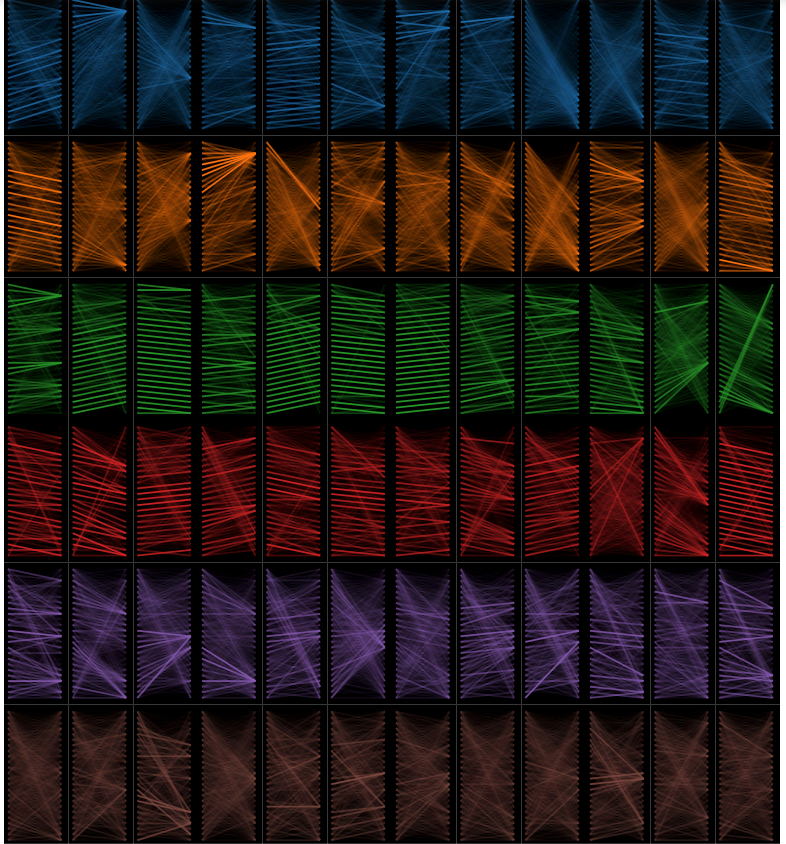

# 뉴런별(Neuron-by-neuron) 뷰:




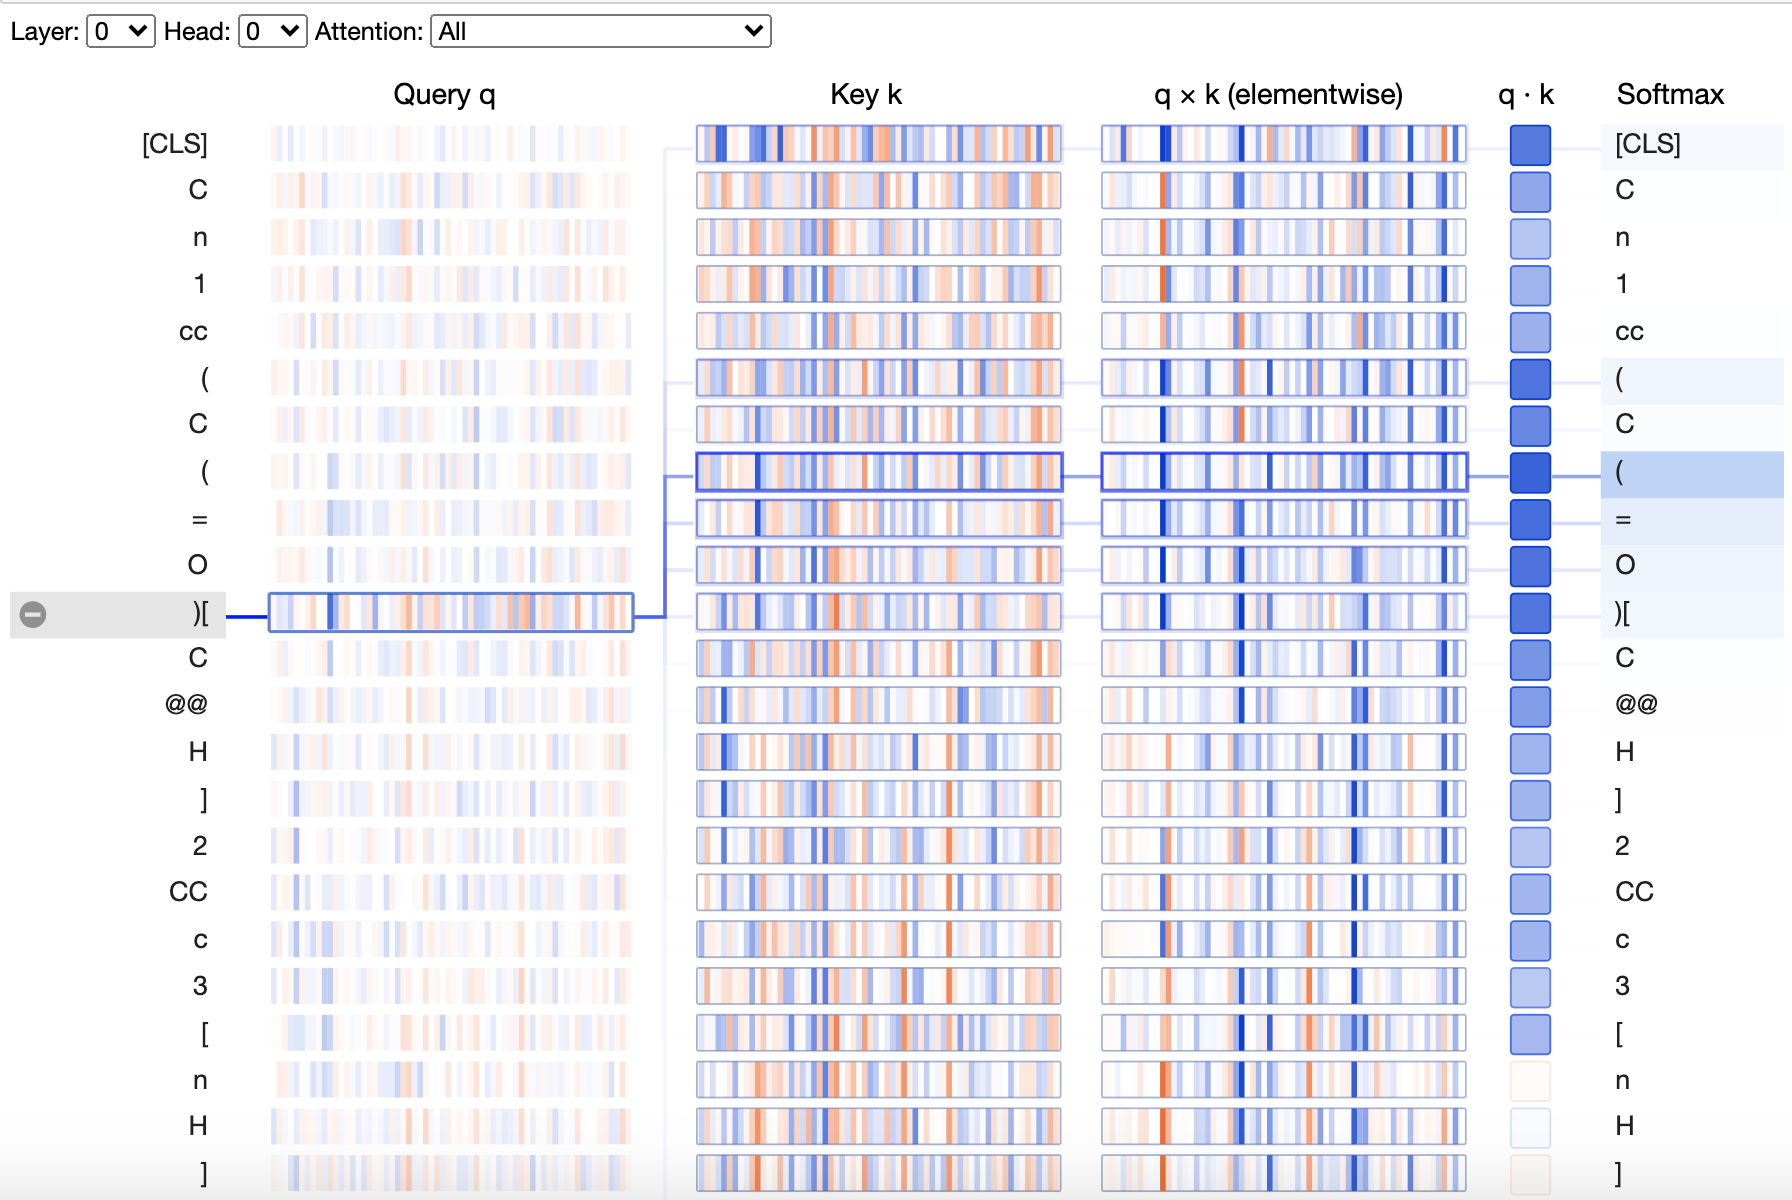

공개 라이브러리 [여기](https://github.com/seyonechithrananda/bert-loves-chemistry)에서 사용자 정의 SMILES/SELFIES 문자열, 토크나이저 등을 활용해 ChemBERTa 어텐션 시각화 데모를 더 자세히 시험해볼 수 있습니다.


# 전이학습(Transfer Learning)이란 무엇이며, ChemBERTa는 이를 어떻게 활용하는가?

전이학습은 **하나의 문제를 풀며 얻은 지식을 저장하여, 다르지만 관련된 문제에 적용하는 것**에 초점을 둔 머신러닝의 연구 주제입니다.

SMILES 문자열로 직접 사전학습하고, ChemBERTa가 각 문자열에서 가려진 토큰을 인식하도록 가르치면, 모델은 강력한 분자 표현(molecular representation)을 학습합니다. 그런 다음 이 구조화학 과제로 학습된 모델을 가져와, Tox21부터 BBBP까지 MoleculeNet 모음의 다양한 분류 과제에 적용할 수 있습니다!


# 소규모 분자 데이터셋에서 ChemBERTa 미세조정하기

우리의 미세조정 데이터셋인 ClinTox는, FDA 승인 약물과 독성 문제로 임상시험에 실패한 약물에 대한 정성적(qualitative) 데이터로 구성됩니다.

ClinTox 데이터셋은 독성에 대한 1478개의 이진(binary) 레이블로 이루어져 있으며, 분자 식별에 SMILES 표현을 사용합니다. 이 데이터셋으로 만든 계산 모델은, 정부 기관이 어떤 약물이 인체 건강에 가장 큰 잠재적 우려가 되는지 판단하는 의사결정 도구가 될 수 있습니다. 또한 이 모델들은 신약 개발 파이프라인에서 독성에 대한 약물 스크리닝 도구로도 활용될 수 있습니다.


먼저 `bert-loves-chemistry`에서 MolNet 데이터로더를 import합니다. 이 로더로 ClinTox 데이터셋을 스캐폴드 분할(scaffold split)로 불러올 수 있습니다.


In [ ]:
%cd /content/bert-loves-chemistry


In [ ]:
!pwd


In [ ]:
import os

import numpy as np
import pandas as pd

from typing import List

# deepchem에서 molnet 로더들을 import합니다.
from deepchem.molnet import load_bbbp, load_clearance, load_clintox, load_delaney, load_hiv, load_qm7, load_tox21
from rdkit import Chem


# bert-loves-chemistry 포크에서 MolNet 데이터로더를 import합니다.
from chemberta.utils.molnet_dataloader import load_molnet_dataset, write_molnet_dataset_for_chemprop


# 그런데 왜 BPE 대신 사용자 정의 Smiles-Tokenizer를 쓰는가?

이 튜토리얼에서는 BPE 토큰화 알고리즘을, 정규식(regex) 패턴 기반의 **사용자 정의 SmilesTokenizer**(DeepChem의 일부로 공개)와 비교하겠습니다. 토크나이저를 비교하기 위해, 이 새로운 토크나이저로 토큰화한 동일한 모델을 PubChem-1M 세트에서 사전학습했습니다. 논문에서는 이 사전학습 모델을 BBBP와 Tox21에서 평가했습니다. 그 결과 SmilesTokenizer가 BPE 알고리즘을 ∆PRC-AUC = $+0.021$ 만큼 근소하게 앞섰습니다.

이 결과는 더 의미론적으로 적절한 토큰화가 성능 이점을 줄 수 있음을 시사하지만, 이 발견을 검증하려면 추가 데이터셋에서의 벤치마킹이 더 필요합니다. **이 튜토리얼에서는 ClinTox 데이터셋에서 이 대안 모델을 테스트하여 그 검증을 시도하려 합니다.**

DeepChem S3 데이터 버킷에서 불러올 수 있는, Smiles Tokenizer의 줄당 문자(character per line) 어휘 파일을 가져옵시다:


In [ ]:
!wget https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/vocab.txt


MolNet 데이터로더를 사용해 ClinTox 데이터셋에서 스캐폴드 분할(scaffold split)을 생성하겠습니다.


In [ ]:
tasks, (train_df, valid_df, test_df), transformers = load_molnet_dataset("clintox", tasks_wanted=None)


In [ ]:
train_df

In [ ]:
valid_df

In [ ]:
test_df

이제 HuggingFace `Trainer`로 미세조정하기 위한 도구들을 정의합니다. 데이터셋 변환, 클래스 가중치 계산, 가중 손실을 적용한 `WeightedTrainer`, 평가 지표(정확도·PRC-AUC), 그리고 모델 구성·예측 함수를 한 셀에 모아 정의합니다.


In [ ]:
# === HuggingFace Trainer 기반 미세조정 도구 정의 ===
# (원본의 simpletransformers를 대체합니다. 최신 transformers와 호환됩니다.)
import numpy as np
import torch
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import accuracy_score, average_precision_score

import logging
logging.basicConfig(level=logging.INFO)
logging.getLogger("transformers").setLevel(logging.WARNING)


def make_datasets(tokenizer, max_length=128):
    """데이터프레임(첫 열=SMILES, 둘째 열=레이블)을 토큰화된 HF Dataset으로 변환."""
    def to_ds(df):
        df2 = df.iloc[:, :2].copy()
        df2.columns = ["text", "labels"]
        d = Dataset.from_pandas(df2.reset_index(drop=True))
        return d.map(lambda b: tokenizer(b["text"], truncation=True, max_length=max_length),
                     batched=True)
    return {"train": to_ds(train_df), "valid": to_ds(valid_df), "test": to_ds(test_df)}


def class_weights_from(df):
    """불균형 데이터 보정을 위한 클래스 가중치 (simpletransformers의 auto_weights에 해당)."""
    y = np.asarray(df.iloc[:, 1])
    classes, counts = np.unique(y, return_counts=True)
    return torch.tensor(counts.sum() / (len(classes) * counts), dtype=torch.float)


class WeightedTrainer(Trainer):
    """클래스 가중치를 적용한 교차 엔트로피 손실을 쓰는 Trainer."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        w = None if self.class_weights is None else self.class_weights.to(outputs.logits.device)
        loss = torch.nn.CrossEntropyLoss(weight=w)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    """정확도와 PRC-AUC(평균 정밀도)를 계산."""
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    preds = logits.argmax(-1)
    return {"accuracy": accuracy_score(labels, preds),
            "prc_auc": average_precision_score(labels, probs)}


def build(model_name, num_train_epochs, output_dir):
    """사전학습 모델을 불러와 분류용 Trainer를 구성합니다."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    ds = make_datasets(tokenizer)
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",     # 매 에폭마다 검증
        save_strategy="no",
        logging_steps=50,
        report_to="none",          # 외부 실험 로깅 비활성화
    )
    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=ds["train"], eval_dataset=ds["valid"],
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        class_weights=class_weights_from(train_df),
    )
    return trainer, tokenizer, ds


def predict_smiles(trainer, tokenizer, smiles_list):
    """단일/여러 SMILES에 대한 (예측 클래스, 클래스별 확률)을 반환."""
    enc = tokenizer(smiles_list, return_tensors="pt", padding=True, truncation=True).to(trainer.model.device)
    with torch.no_grad():
        logits = trainer.model(**enc).logits
    return logits.argmax(-1).tolist(), torch.softmax(logits, dim=-1).tolist()


이제 HuggingFace `transformers`의 `Trainer`를 사용해 모델 허브의 사전학습 모델을 미세조정합니다. 에폭 수를 10으로 설정하지만 더 길게 학습할 수도 있습니다. 또한 불균형(imbalanced) 독성 데이터셋이므로, 위에서 정의한 `WeightedTrainer`가 클래스 가중치를 자동으로 적용합니다(원본의 `auto_weights`에 해당).


In [ ]:
# BPE 토크나이저 기반 ChemBERTa를 불러와 분류용 Trainer를 구성합니다 (10 에폭).
bpe_trainer, bpe_tokenizer, bpe_ds = build(
    "seyonec/PubChem10M_SMILES_BPE_396_250",
    num_train_epochs=10,
    output_dir="BPE_PubChem_10M_ClinTox_run",
)


In [ ]:
print(bpe_tokenizer)


In [ ]:
# 학습/평가 데이터프레임이 올바르게 설정됐는지 확인합니다. SMILES 문자열과 해당 레이블, 두 개의 열만 있어야 합니다.
print("Train Dataset: {}".format(train_df.shape))
print("Eval Dataset: {}".format(valid_df.shape))
print("TEST Dataset: {}".format(test_df.shape))


이제 학습을 시작합니다! 매 에폭마다 검증 세트로 모델 성능을 평가합니다.


In [ ]:
# ClinTox 학습 세트로 모델을 미세조정합니다. 매 에폭마다 검증 세트로 평가합니다.
bpe_trainer.train()


이제 학습한 모델을 테스트 세트에서 평가합니다. 정확도(accuracy)와 PRC-AUC(평균 정밀도, average precision)를 지표로 사용합니다.


In [ ]:
# 테스트 세트에서 정확도와 PRC-AUC(평균 정밀도)를 평가합니다.
print(bpe_trainer.evaluate(bpe_ds["test"]))


이 모델은 단 ~1400개의 데이터 샘플과 150개의 양성(positive) 후보물질만으로 몇 분 만에 학습했음에도, 평균 97% 이상의 PRC-AUC를 기록하며 꽤 잘 동작합니다! 전이학습의 예측력을 분명히 확인할 수 있으며, 이런 접근법은 큰 데이터셋이 드문 제약 산업에서 점점 인기를 얻고 있습니다. 더 많은 에폭과 과제로 학습하면 정확도를 더 높일 수도 있습니다!

ClinTox 테스트 세트의 마지막 문자열 하나로 독성에 대해 모델을 평가해 봅시다. 모델은 1을 예측해야 합니다. 즉, 그 약물이 독성 문제로 임상시험에 실패했고 FDA 승인을 받지 못했음을 의미합니다.


In [ ]:
# 독성 값이 1인 분자를 입력해 봅니다. (1 = 임상시험 실패/미승인)
preds, probs = predict_smiles(bpe_trainer, bpe_tokenizer, ['C1=C(C(=O)NC(=O)N1)F'])


In [ ]:
print(preds)
print(probs)


모델이 샘플을 올바르게 예측했습니다! 앞으로의 과제로는, 같은 모델을 다중 과제(multi-task) 분류로 여러 과제에 사용하거나(예를 들어 Tox21은 독성과 관련된 여러 생화학 경로에 대한 다중 과제를 제공합니다), HIV처럼 분자 머신러닝에서 더 어려운 과제 중 하나인 더 큰 데이터셋에서 학습하는 것 등이 있습니다. 이는 향후 연구에서 확장될 예정입니다!

# ClinTox에서 Smiles-Tokenizer ChemBERTa 모델 벤치마킹

이제 이 모델이, 다른 토크나이저인 [SmilesTokenizer](https://deepchem.readthedocs.io/en/latest/api_reference/tokenizers.html)(DeepChem에 내장)를 사용하는 유사한 ChemBERTa 변형과 비교해 어떻게 동작하는지 비교해 봅시다. SMILES 시퀀스를 문법적으로 의미 있는 화학 토큰으로 분할하는 토크나이저를 쓰면, 특히 분자 물성 예측에서 성능이 다른지 살펴보겠습니다.

먼저 이 변형 모델을 초기화합시다:


In [ ]:
# SmilesTokenizer 기반 ChemBERTa를 불러와 분류용 Trainer를 구성합니다 (15 에폭).
st_trainer, st_tokenizer, st_ds = build(
    "seyonec/SMILES_tokenized_PubChem_shard00_160k",
    num_train_epochs=15,
    output_dir="SmilesTokenizer_PubChem_10M_ClinTox_run",
)


In [ ]:
print(st_tokenizer)


In [ ]:
# 학습/평가 데이터프레임이 올바르게 설정됐는지 확인합니다. SMILES 문자열과 해당 레이블, 두 개의 열만 있어야 합니다.
print("Train Dataset: {}".format(train_df.shape))
print("Eval Dataset: {}".format(valid_df.shape))
print("TEST Dataset: {}".format(test_df.shape))


이제 학습을 시작합니다! 매 에폭마다 검증 세트로 모델 성능을 평가합니다.


In [ ]:
# ClinTox 학습 세트로 모델을 미세조정합니다. 매 에폭마다 검증 세트로 평가합니다.
st_trainer.train()


이제 학습한 모델을 테스트 세트에서 평가합니다. 정확도(accuracy)와 PRC-AUC(평균 정밀도, average precision)를 지표로 사용합니다.


In [ ]:
# 테스트 세트에서 정확도와 PRC-AUC(평균 정밀도)를 평가합니다.
print(st_trainer.evaluate(st_ds["test"]))


이 모델은 단 ~1400개의 데이터 샘플과 150개의 양성 후보물질만으로 몇 분 만에 학습했음에도, 평균 96% 이상의 PRC-AUC를 기록하며 놀라울 만큼 잘 동작합니다! 이 모델은 앞서 사용한 PubChem-10M BPE 모델의 1/10 분량의 사전학습 데이터로 학습되었지만, 여전히 견고한 성능을 보여줍니다. 전이학습의 예측력을 분명히 확인할 수 있으며, 이런 접근법은 큰 데이터셋이 드문 제약 산업에서 점점 인기를 얻고 있습니다. 더 많은 에폭과 과제로 학습하면 정확도를 더 높일 수도 있습니다!

ClinTox 테스트 세트의 마지막 문자열 하나로 독성에 대해 모델을 평가해 봅시다. 모델은 1을 예측해야 합니다. 즉, 그 약물이 독성 문제로 임상시험에 실패했고 FDA 승인을 받지 못했음을 의미합니다.


In [ ]:
# 독성 값이 1인 분자를 입력해 봅니다. (1 = 임상시험 실패/미승인)
preds, probs = predict_smiles(st_trainer, st_tokenizer, ['C1=C(C(=O)NC(=O)N1)F'])


In [ ]:
print(preds)
print(probs)


모델이 샘플을 올바르게 예측했습니다! 앞으로의 과제로는, 같은 모델을 다중 과제 분류로 여러 과제에 사용하거나(예를 들어 Tox21은 독성과 관련된 여러 생화학 경로에 대한 다중 과제를 제공합니다), HIV처럼 분자 머신러닝에서 더 어려운 과제 중 하나인 더 큰 데이터셋에서 학습하는 것 등이 있습니다. 이는 향후 연구에서 확장될 예정입니다!
